Cabrina Smith

Today, we will be taking a closer look at FIFA rankings to see if we can accurately predict which countries qualify for the World Cup. The dataset used for this analysis was sourced from Kaggle:

https://www.kaggle.com/datasets/tadhgfitzgerald/fifa-international-soccer-mens-ranking-1993now

Below, we import pandas, matplotlib.pyplot, numpy, scikit-learn, and seaborn to build our analytical pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns


We begin by loading the data and filtering for the specific tournament cycles where we have complete historical records. By narrowing our view to the ranking snapshots immediately preceding the 1998, 2002, 2006, 2010, and 2014 tournaments, we ensure we are working with the data that directly impacted those World Cups. Additionally, we will map a dedicated column for the World Cup year to keep our dataframe organized and efficient.

In [2]:
# bring in raw data from csv file
raw_df = pd.read_csv('fifa_ranking.csv')

# define "world cup" dates for ranking
target_dates = {
    1998: '1998-05-20',
    2002: '2002-05-15',
    2006: '2006-05-17',
    2010: '2010-05-26',
    2014: '2014-05-08'
}

# df = data frame that only includes dates 1998,2002,2006,2010,2014
df = raw_df[raw_df['rank_date'].isin(target_dates.values())].copy()

# add column for world cup year -so I know
date_to_year = {v: k for k, v in target_dates.items()}
df['wc_year'] = df['rank_date'].map(date_to_year)

print(f"Snapshot dataset created! Total rows: {df.shape[0]}")

Snapshot dataset created! Total rows: 1017


Because the original dataset does not explicitly flag which countries qualified for the World Cup in a given cycle, historical qualification records were collected externally to serve as our target criteria.

Let's apply this qualification map to our dataframe to establish our binary target column (Made_World_Cup) and inspect the initial distribution.

In [3]:
# Lists of actual qualified teams for each World Cup year
qualified_teams = {
    1998: ['France', 'Brazil', 'Germany', 'Italy', 'Argentina', 'Spain', 'Netherlands', 'Romania', 
           'England', 'Belgium', 'Yugoslavia', 'Colombia', 'Norway', 'Croatia', 'Bulgaria', 'Morocco', 
           'Denmark', 'Tunisia', 'Chile', 'Austria', 'Japan', 'South Africa', 'Saudi Arabia', 'Iran', 
           'Jamaica', 'Paraguay', 'United States', 'South Korea', 'Mexico', 'Nigeria', 'Cameroon', 'Scotland'],
    
    2002: ['South Korea', 'Japan', 'France', 'Brazil', 'Argentina', 'Italy', 'Germany', 'Spain', 
           'England', 'Mexico', 'Portugal', 'Slovenia', 'Turkey', 'China PR', 'Ecuador', 'Paraguay', 
           'Croatia', 'Denmark', 'Sweden', 'Republic of Ireland', 'Russia', 'Belgium', 'Poland', 
           'Cameroon', 'Nigeria', 'Senegal', 'Tunisia', 'South Africa', 'Costa Rica', 'United States', 'Uruguay', 'Saudi Arabia'],
    
    2006: ['Germany', 'Brazil', 'Argentina', 'Italy', 'Spain', 'England', 'France', 'Mexico', 
           'Portugal', 'Netherlands', 'Czech Republic', 'Croatia', 'Tunisia', 'South Korea', 'Japan', 
           'Saudi Arabia', 'Iran', 'Togo', 'Ghana', 'Ivory Coast', 'Angola', 'Tunisia', 
           'Ecuador', 'Paraguay', 'Trinidad and Tobago', 'Costa Rica', 'United States', 'Australia', 'Switzerland', 'Ukraine', 'Poland', 'Sweden', 'Serbia and Montenegro'],
    
    2010: ['South Africa', 'Brazil', 'Spain', 'Netherlands', 'Italy', 'Germany', 'Argentina', 'England', 
           'France', 'Portugal', 'Slovenia', 'Greece', 'Algeria', 'Ghana', 'Ivory Coast', 'Nigeria', 
           'Cameroon', 'Japan', 'South Korea', 'Australia', 'North Korea', 'New Zealand', 'United States', 
           'Mexico', 'Honduras', 'Chile', 'Paraguay', 'Uruguay', 'Switzerland', 'Slovakia', 'Denmark', 'Serbia'],
    
    2014: ['Brazil', 'Spain', 'Germany', 'Argentina', 'Colombia', 'Belgium', 'Uruguay', 'Switzerland', 
           'Netherlands', 'Italy', 'England', 'Portugal', 'Greece', 'Bosnia and Herzegovina', 'Croatia', 
           'Russia', 'France', 'Chile', 'Ecuador', 'Ivory Coast', 'Ghana', 'Algeria', 'Nigeria', 
           'Cameroon', 'Australia', 'Iran', 'Japan', 'South Korea', 'Costa Rica', 'Honduras', 'Mexico', 'United States']
}

#  check qualification
def check_qualification(row):
    year = row['wc_year']
    country = row['country_full']
    if country in qualified_teams[year]:
        return 1
    return 0

# Apply the function to create  target label
df['Made_World_Cup'] = df.apply(check_qualification, axis=1)

# verify how many teams are marked as qualified vs not
print(df.groupby('wc_year')['Made_World_Cup'].value_counts())

df.head()

wc_year  Made_World_Cup
1998     0                 163
         1                  29
2002     0                 173
         1                  30
2006     0                 177
         1                  28
2010     0                 179
         1                  28
2014     0                 182
         1                  28
Name: count, dtype: int64


,rank,country_full,country_abrv,total_points,previous_points,rank_change,cur_year_avg,cur_year_avg_weighted,last_year_avg,last_year_avg_weighted,two_year_ago_avg,two_year_ago_weighted,three_year_ago_avg,three_year_ago_weighted,confederation,rank_date,wc_year,Made_World_Cup
8696,1,Brazil,BRA,0.0,72,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CONMEBOL,1998-05-20,1998,1
8697,2,Germany,GER,0.0,65,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UEFA,1998-05-20,1998,1
8698,3,Czech Republic,CZE,0.0,64,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UEFA,1998-05-20,1998,0
8699,4,Mexico,MEX,0.0,60,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CONCACAF,1998-05-20,1998,1
8700,5,England,ENG,0.0,59,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UEFA,1998-05-20,1998,1


Looking closely at our value counts(1 rows), we hit a clear data entry bottleneck. Each tournament cycle from 1998 through 2014 should show exactly 32 qualifying teams. Instead, our target assignments are dropping short—capturing only 29 teams in 1998 and 30 teams in several other years.

This variance is driven by nominal discrepancies between official country names in the dataset and common names used in our qualification list (e.g., "United States" vs. "USA"). The current string matching code fails to capture these variations. Let's isolate the missing country names systematically.

In [4]:
# RFinding the mismatching country codes
print("RUNNING DATA COUNTRY MISMATCH CHECK...\n")

for year,teams in qualified_teams.items():
    # find country names for each year
    dataset_countries = df[df['wc_year'] == year]['country_full'].unique()
    # find what country names are missing
    missing_teams = [team for team in teams if team not in dataset_countries]
    
    # print for tounaments that do not have all 32 teams
    if missing_teams:
        print(f"*** Year {year} : Missing {len(missing_teams)} team names from dataset.")
        for team in missing_teams:
            print(f"  Expected Team Name: '{team}'")

RUNNING DATA COUNTRY MISMATCH CHECK...

*** Year 1998 : Missing 3 team names from dataset.
  Expected Team Name: 'Iran'
  Expected Team Name: 'United States'
  Expected Team Name: 'South Korea'
*** Year 2002 : Missing 2 team names from dataset.
  Expected Team Name: 'South Korea'
  Expected Team Name: 'United States'
*** Year 2006 : Missing 4 team names from dataset.
  Expected Team Name: 'South Korea'
  Expected Team Name: 'Iran'
  Expected Team Name: 'Ivory Coast'
  Expected Team Name: 'United States'
*** Year 2010 : Missing 4 team names from dataset.
  Expected Team Name: 'Ivory Coast'
  Expected Team Name: 'South Korea'
  Expected Team Name: 'North Korea'
  Expected Team Name: 'United States'
*** Year 2014 : Missing 4 team names from dataset.
  Expected Team Name: 'Ivory Coast'
  Expected Team Name: 'Iran'
  Expected Team Name: 'South Korea'
  Expected Team Name: 'United States'


Now that we have identified the missing country records, we can look up their alternative names within the dataset to apply a standardized mapping.

In [5]:
# Query the dataset for any country name containing the keyword "Korea"
print(df[df['country_full'].str.contains("Korea", case=False)]['country_full'].unique())


# Query the dataset for any country name containing the keyword "Iran"
print(df[df['country_full'].str.contains("Iran", case=False)]['country_full'].unique())



['Korea Republic' 'Korea DPR']
['IR Iran']


Our search confirms that 'Korea Republic' represents South Korea, 'Korea DPR' represents North Korea, 'IR Iran' is used for Iran, and 'Côte d'Ivoire' is used for the Ivory Coast. We can now construct a dictionary to align and replace these names globally, ensuring our model training target is clean and accurate.

In [6]:
# Query the dataset for any country abbreviation equal to USA
print(df[df['country_abrv'] == 'USA']['country_full'].unique())

# Query the dataset for any country abbreviation that starts with 'C' 
# for Ivory Cost AKA: Cote d'Ivoire
print(df[df['country_full'].str.startswith("C")]['country_full'].unique())


['USA']
['Czech Republic' 'Chile' 'Colombia' 'Croatia' "Côte d'Ivoire" 'Cameroon'
 'China PR' 'Costa Rica' 'Canada' 'Cyprus' 'Cuba' 'Congo' 'Cambodia'
 'Chinese Taipei' 'Cape Verde Islands' 'Cayman Islands' 'Chad'
 'Central African Republic' 'Cook Islands' 'Congo DR' 'Comoros' 'Curaçao']


Now that we have a list of the full names that start with the letter C, we can find Ivory Coast or Cote d'Ivoire is the 5th on the list. We can now standardize the names that were missing in our above list. 

In [7]:
# Name Corretiions
name_corrections = {
    'USA': 'United States',
    'Korea Republic' : 'South Korea',
    'Korea DPR': 'North Korea',
    'IR Iran': "Iran",
    "Côte d'Ivoire": 'Ivory Coast'
}

# apply name corrections to country column in dataset
df['country_full'] = df['country_full'].replace(name_corrections)


# apply to create the target lable
df['Made_World_Cup']= df.apply(check_qualification, axis=1)

# print to verify
print("--- Cleaned Results ---")
print(df.groupby('wc_year')['Made_World_Cup'].value_counts())

--- Cleaned Results ---
wc_year  Made_World_Cup
1998     0                 160
         1                  32
2002     0                 171
         1                  32
2006     0                 173
         1                  32
2010     0                 175
         1                  32
2014     0                 178
         1                  32
Name: count, dtype: int64


With our 32 qualifying teams fully accounted for across all tournament cycles, we want to evaluate the completeness of our metric tracking columns—specifically total_points and previous_points.

In [8]:
# checking the average of values accross World Cup years
print("Checking 'total_points' average per World Cup by year:")
print(df.groupby('wc_year')['total_points'].mean())

print("\nChecking 'previous_points' average per World Cup by year:")
print(df.groupby('wc_year')['previous_points'].mean())

Checking 'total_points' average per World Cup by year:
wc_year
1998      0.000000
2002      0.000000
2006      0.000000
2010      0.000000
2014    383.005381
Name: total_points, dtype: float64

Checking 'previous_points' average per World Cup by year:
wc_year
1998     29.651042
2002    406.408867
2006    423.146341
2010    382.628019
2014    381.942857
Name: previous_points, dtype: float64


The validation printout exposes a fatal issue: the total_points column was not systematically tracked prior to 2014, resulting in values of 0.0 for the first four tournament cycles. Relying on this feature would introduce a massive historical bias and compromise our model's logic. Consequently, we will discard all point-based averages and instead leverage rank, rank_change, and confederation as our core predictors.

In [9]:
clean_df = df[['wc_year', 'country_full', 'rank', 'rank_change', 'confederation', 'Made_World_Cup']].copy()

print(f"Data Filtered! Cleaned Shape: {clean_df.shape}")
print(clean_df.head())

Data Filtered! Cleaned Shape: (1017, 6)
      wc_year    country_full  rank  rank_change confederation  Made_World_Cup
8696     1998          Brazil     1            0      CONMEBOL               1
8697     1998         Germany     2            0          UEFA               1
8698     1998  Czech Republic     3            0          UEFA               0
8699     1998          Mexico     4            0      CONCACAF               1
8700     1998         England     5            0          UEFA               1


To optimize our categorical modeling approach for Naive Bayes, we will segment our continuous ranking data into discrete ordinal bins.

In [10]:
# select columns and make copy
clean_df = df[['wc_year', 'country_full', 'rank', 'rank_change', 'confederation','Made_World_Cup']].copy()
# remove warning
clean_df = clean_df.reset_index(drop=True)

#create new rank tiers
clean_df['rank_tier'] = pd.qcut(clean_df['rank'], q = 5, labels=['Tier 1 (Elite)', 'Tier 2 (High)', 'Tier 3 (Mid)', 'Tier 4 (Low)', 'Tier 5 (Bottom)'])

#print
print(pd.crosstab(clean_df['rank_tier'], clean_df['Made_World_Cup'], normalize='index') * 100)

Made_World_Cup            0          1
rank_tier                             
Tier 1 (Elite)    32.682927  67.317073
Tier 2 (High)     90.243902   9.756098
Tier 3 (Mid)      99.009901   0.990099
Tier 4 (Low)     100.000000   0.000000
Tier 5 (Bottom)  100.000000   0.000000


The cross-tabulation clearly reveals the power of our ranking tiers: approximately 67.3% of "Elite" (Tier 1) teams successfully qualify for the World Cup, while less than 10% of "High" (Tier 2) teams and less than 1% of "Mid" (Tier 3) teams manage to secure a slot. Lower-tier nations consistently fail to qualify entirely.

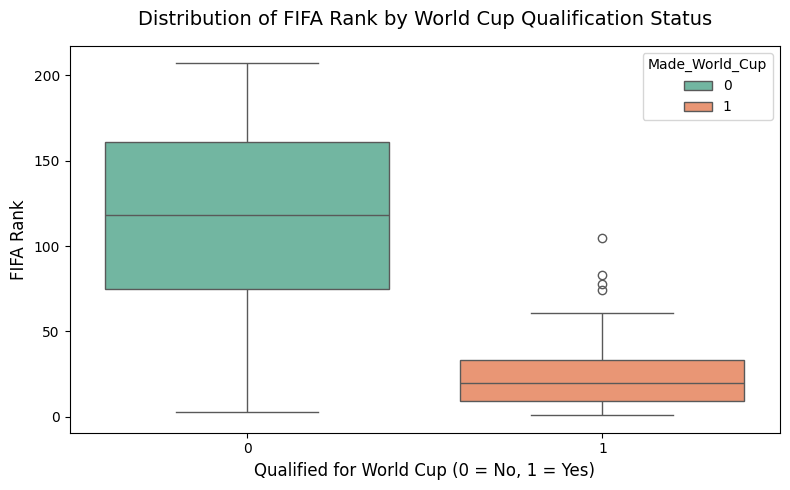

In [11]:
# BOX PLOT of rank distribuitons
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(x='Made_World_Cup', y='rank', data=clean_df, ax=ax,hue='Made_World_Cup', palette= 'Set2')

ax.set_title('Distribution of FIFA Rank by World Cup Qualification Status', fontsize=14, pad=15)
ax.set_xlabel('Qualified for World Cup (0 = No, 1 = Yes)', fontsize = 12)
ax.set_ylabel('FIFA Rank', fontsize = 12)

plt.tight_layout()
plt.savefig('rank_distribuiton_boxplot.png', dpi = 300)

The distribution plot highlights a stark separation in global rank between nations that qualify for the World Cup (1) and those that do not (0). Aside from a few competitive outliers, the vast majority of qualifying teams sit well below a global FIFA rank of 50.

Because FIFA allocates regional qualifying berths disproportionately across continents, we should also examine qualification distributions across specific global confederations—such as Europe (UEFA) versus Oceania (OFC).

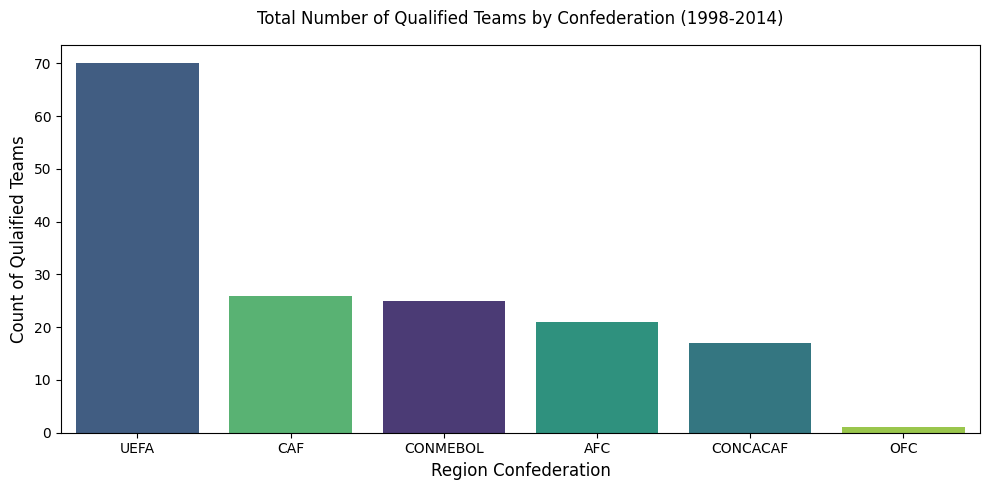

In [12]:
# PLOT World Cup Slots by Confederation (global region)
# filter- only teams who successfuly qualified for World Cup
qualified_only = clean_df[clean_df['Made_World_Cup']==1]

fig, ax = plt.subplots(figsize=(10,5))

# plotting counts of qualified teams highest to lowest
sns.countplot(x='confederation',
    data=qualified_only,
    ax=ax,
    order= qualified_only['confederation'].value_counts().index,
    hue='confederation',
    palette='viridis',
    legend=False
)

ax.set_title('Total Number of Qualified Teams by Confederation (1998-2014)', fontsize=12,pad=15)
ax.set_xlabel('Region Confederation', fontsize=12)
ax.set_ylabel('Count of Qulaified Teams', fontsize=12)

plt.tight_layout()
plt.savefig('confederation_qualification_counts.png', dpi=300)

The visual breakdown reveals that Europe (UEFA) heavily dominates global tournament access, capturing just under 70 slots across our historical timeline. Conversely, Africa (CAF), Asia (AFC), South America (CONMEBOL), and North/Central America (CONCACAF) exhibit a more equitable, clustered baseline of representation. Oceania (OFC) sits at the absolute bottom, highlighting how difficult it is for that region to secure an active World Cup slot.

With our descriptive data exploration complete, we can now step into model training with Naive Bayes.

In [13]:
# train- test split

# predictors and target
X_nb = clean_df[['confederation','rank_tier']]
y = clean_df['Made_World_Cup']

# encode categorical strings to binary categories
X_nb_encoded = pd.get_dummies(X_nb, drop_first=False)

# using 1998-2010 data to train---- 2014 for test
train_mask = clean_df['wc_year']<2014
test_mask = clean_df['wc_year'] == 2014

X_train, X_test = X_nb_encoded[train_mask], X_nb_encoded[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Features successfully preprocessed.")
print(f"Training Observations (1998-2010): {X_train.shape[0]}")
print(f"Testing Observations (2014): {X_test.shape[0]}")

Features successfully preprocessed.
Training Observations (1998-2010): 807
Testing Observations (2014): 210


We split our dataset chronologically to mimic a real-world predictive scenario. We train our classifiers on historical data spanning from 1998 to 2010 (807 observations) and set aside the 2014 tournament (210 observations) as a completely unseen testing subset to validate our model's predictive generalization.

Model interations completed and plot saved!


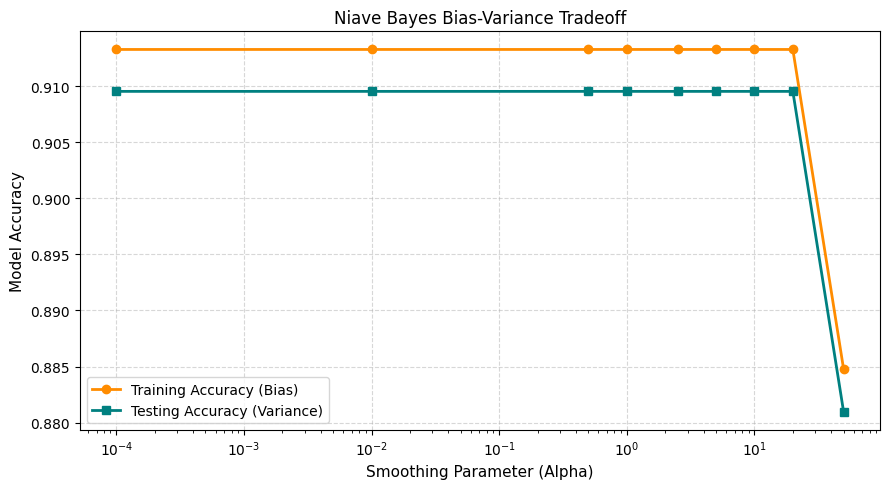

In [14]:
# ranges of 'alpha' values to test bias-variance 
alphas = [0.0001, 0.01, 0.5, 1.0, 2.5, 5.0, 10.0, 20.0, 50.0]
train_accuracies = []
test_accuracies = []

# loop through each alpha
for a in alphas:
    nb = CategoricalNB(alpha=a)
    nb.fit(X_train, y_train)
    
    # calculate metrics
    train_acc = accuracy_score(y_train, nb.predict(X_train))
    test_acc = accuracy_score(y_test, nb.predict(X_test))
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

#Visualization of Bias-Variance Tradeoff
plt. figure(figsize= (9,5))
plt.plot(alphas, train_accuracies, marker= 'o', label= 'Training Accuracy (Bias)', color='darkorange', linewidth=2)
plt.plot(alphas, test_accuracies, marker='s', label = 'Testing Accuracy (Variance)', color = 'teal', linewidth=2)

plt.xscale('log')
plt.title('Niave Bayes Bias-Variance Tradeoff')
plt.xlabel('Smoothing Parameter (Alpha)', fontsize = 11)
plt.ylabel('Model Accuracy', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha = 0.5)
plt.tight_layout()

# save plot
plt.savefig('niave_bayes_bias_variance_cureve.png', dpi=300)
print("Model interations completed and plot saved!")


Looking at our Naive Bayes plot, we can see that the model is performing quite well overall. Both the training and testing accuracy lines stay up above 90%. Because the training line (orange) and testing line (teal) hug each other closely across almost the entire graph, we can tell our model has low variance and generalizes well to unseen data.

However, because our categorical features were split into simple 1s and 0s using dummy variables, changing the alpha value from 0.0001 to 10.0 barely changes the internal probability math. This explains why the accuracy lines look completely flat for most of the graph. The sharp drop at alpha = 50 happens because the smoothing parameter becomes too large, causing the model to lose the signal in the data and underfit (high bias).

Since this graph doesn't give us that classic "X-shaped" bias-variance trade-off curve where one line goes up and the other goes down, let's try an alternative approach. We will use a Decision Tree Classifier on our continuous features (rank and rank_change) and change the max depth parameter to see how model complexity changes things.

In [15]:
# find alpha that creates best test performance
best_index = np.argmax(test_accuracies)
optimal_alpha = alphas[best_index]

print(f"Optimal Tuning Configuration at Alpha = {optimal_alpha}")
print(f"Highest Unseen 2014 Validation Accuracy: {test_accuracies[best_index]* 100:.2f}%\n")

# re-run model for hyperparameter setting 
optimal_nb = CategoricalNB(alpha=optimal_alpha)
optimal_nb.fit(X_train, y_train)
final_preds = optimal_nb.predict(X_test)

print("*** Final Model Evaluation Report ***")
print(classification_report(y_test, final_preds))

Optimal Tuning Configuration at Alpha = 0.0001
Highest Unseen 2014 Validation Accuracy: 90.95%

*** Final Model Evaluation Report ***
              precision    recall  f1-score   support

           0       0.97      0.92      0.95       178
           1       0.66      0.84      0.74        32

    accuracy                           0.91       210
   macro avg       0.81      0.88      0.84       210
weighted avg       0.92      0.91      0.91       210



Our final model evaluation report details strong predictive utility given our simplified category groupings. For teams that did not qualify for the tournament (Class 0), our model achieved a 97% precision score. For teams that did successfully qualify (Class 1), the model captured 84% of them (recall), showing that ranking and regional confederations serve as incredibly accurate indicators of World Cup entry.

Finally, our Decision Tree curve illustrates a textbook bias-variance trade-off. At lower maximum depths, the model is simple and holds stable. As complexity increases (higher max depth), the training accuracy continues climbing past 97% (low bias), but the test accuracy visibly drops off (high variance)—demonstrating the exact point where a complex model begins to overfit its training data.

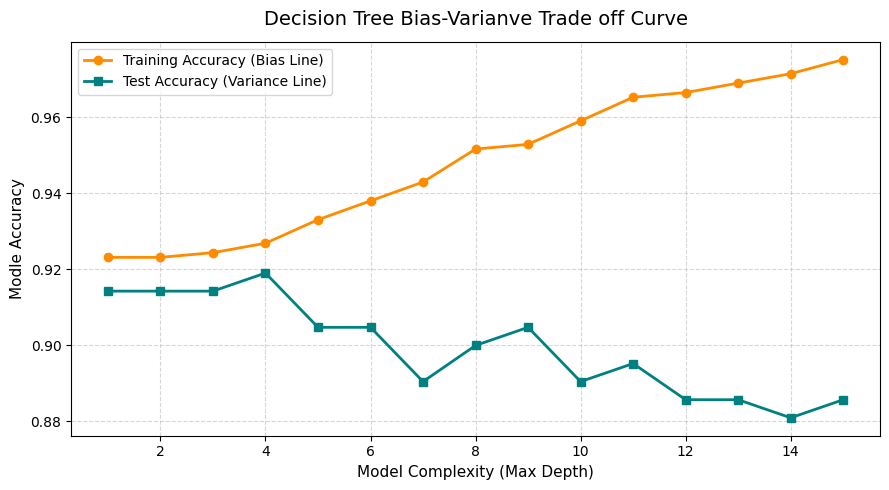

All metrics evaluated adn new trade off curve created successfully!


In [16]:
# Decision Tree- Bias Variance Trade off

# continuous inputs- variance behvior (predictors & target)
X_dt = clean_df[['rank','rank_change']]
y = clean_df['Made_World_Cup']

# using 1998-2010 data to train---- 2014 for test
train_mask = clean_df['wc_year']<2014
test_mask = clean_df['wc_year'] == 2014

X_train, X_test = X_dt[train_mask], X_dt[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

depths = range (1,16)
train_accuracies = []
test_accuracies = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train,y_train)
    
    train_accuracies.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, dt.predict(X_test)))

# graph of bias-variance trade-off
fig, ax= plt.subplots(figsize=(9,5))
ax.plot(depths, train_accuracies, marker= 'o', label='Training Accuracy (Bias Line)', color='darkorange', linewidth=2)
ax.plot(depths, test_accuracies, marker='s', label='Test Accuracy (Variance Line)', color= 'teal', linewidth=2)

ax.set_title('Decision Tree Bias-Varianve Trade off Curve', fontsize=14, pad=12)
ax.set_xlabel('Model Complexity (Max Depth)', fontsize=11)
ax.set_ylabel('Modle Accuracy', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('decision_tree_bias_variance_tradeoff.png', dpi=300)
plt.show()
plt.close()

print("All metrics evaluated adn new trade off curve created successfully!")
